In [11]:
#Load in the packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [12]:
#read in the dataset
import pandas as pd

# Read in TSV file
df = pd.read_csv(r'Data/igsr_samples.tsv', sep='\t')

# Display the first few rows to check if everything worked
df.head()

,Sample name,Sex,Biosample ID,Population code,Population name,Superpopulation code,Superpopulation name,Population elastic ID,Data collections
0,HG00152,male,SAME124593,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1KG_ONT_VIENNA,1000 Gen..."
1,HG00157,male,SAME124590,GBR,British,EUR,European Ancestry,GBR,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
2,HG00171,female,SAME124961,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
3,HG00176,female,SAME124956,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."
4,HG00183,male,SAME123642,FIN,Finnish,EUR,European Ancestry,FIN,"1000 Genomes on GRCh38,1000 Genomes 30x on GRC..."


In [13]:
#descriptive statistics
df.info()
print (df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4989 entries, 0 to 4988
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Sample name            4989 non-null   object
 1   Sex                    4989 non-null   object
 2   Biosample ID           3744 non-null   object
 3   Population code        3915 non-null   object
 4   Population name        4989 non-null   object
 5   Superpopulation code   3912 non-null   object
 6   Superpopulation name   4989 non-null   object
 7   Population elastic ID  4989 non-null   object
 8   Data collections       4893 non-null   object
dtypes: object(9)
memory usage: 350.9+ KB
Sample name                 0
Sex                         0
Biosample ID             1245
Population code          1074
Population name             0
Superpopulation code     1077
Superpopulation name        0
Population elastic ID       0
Data collections           96
dtype: int64


In [14]:

#which Superpopulation names have no code
no_superpop_name = df[df['Superpopulation code'].isnull()][["Population name","Superpopulation name"]].value_counts()
print(no_superpop_name)

Population name  Superpopulation name                       
Bedouin          Middle East (HGDP)                             44
Palestinian      Middle East (HGDP)                             43
Druze            Middle East (HGDP)                             40
Han              East Asia (HGDP)                               30
Japanese         East Asia (HGDP)                               27
                                                                ..
Polish           West Eurasia (SGDP)                             1
Norwegian        West Eurasia (SGDP)                             1
Pathan,Pathan    South Asia (SGDP),Central South Asia (HGDP)     1
Pathan           South Asia (SGDP)                               1
Somali           Africa (SGDP)                                   1
Name: count, Length: 179, dtype: int64


In [15]:
#does the absence of a superpopulation code in the data apply for all of the entries in the country?
# Check whether countries have all, mixed or none of the superpopulation code
pop_code_status = df.groupby('Population name')['Superpopulation code'].apply(
    lambda x: 'All have code' if x.notna().all() 
              else ('none have code' if x.isna().all() 
              else 'mixed')
)

print("=== Status per Population ===")
print(pop_code_status.value_counts())

mixed_pops = pop_code_status[pop_code_status == 'mixed']
print(f"\n=== mixed populations ({len(mixed_pops)}) ===")
print(mixed_pops.index.tolist())

mixed_details = df[df['Population name'].isin(mixed_pops.index)]
    
print(mixed_details.groupby("Population name")['Superpopulation code'].unique())


=== Status pro Population ===
Superpopulation code
none have code    132
All have code      38
mixed               3
Name: count, dtype: int64

=== mixed populations (3) ===
['Colombian', 'Japanese', 'Yoruba']
Population name
Colombian    [AMR, nan]
Japanese     [EAS, nan]
Yoruba       [AFR, nan]
Name: Superpopulation code, dtype: object


In [16]:
#check for duplicates
print (df.duplicated().sum())
#no duplicates

0


In [17]:
# number of male and female in the dataset
print(df['Sex'].value_counts())

#evaluate number of populations
population_dist = df['Population name'].value_counts()
#print top 5 and bottom 5
print (f"the top 5 populations are: {population_dist.head(5)}")
print (f"the bottom 5 populations are: {population_dist.tail(5)}")

#the top 5 superpopulations and bottom 5
superpopulation_dist = df['Superpopulation name'].value_counts()
print (f"the top 5 superpopulations are: {superpopulation_dist.head(5)}")
print (f"the bottom 5 superpopulations are: {superpopulation_dist.tail(5)}")

Sex
male      2651
female    2338
Name: count, dtype: int64
the top 5 populations are: Population name
Gambian Mandinka        278
Yoruba                  209
CEPH                    184
Esan                    171
Southern Han Chinese    171
Name: count, dtype: int64
the bottom 5 populations are: Population name
Somali       1
Norwegian    1
Samaritan    1
Madiga       1
Chukchi      1
Name: count, dtype: int64
the top 5 superpopulations are: Superpopulation name
African Ancestry        1415
European Ancestry        663
South Asian Ancestry     655
East Asian Ancestry      619
American Ancestry        535
Name: count, dtype: int64
the bottom 5 superpopulations are: Superpopulation name
America (SGDP),America (HGDP)                  2
European Ancestry,African Ancestry             1
East Asia (SGDP),East Asia (HGDP)              1
South Asia (SGDP),Central South Asia (HGDP)    1
Middle East (HGDP),Africa (SGDP)               1
Name: count, dtype: int64


In [18]:
#normalize the samples total superpopulations to their population in the respective continents
#first we sum the superpoulations into their respective continents e.g. South Asian and East Asian into ASIA

continent_population =pd.Series( {
    'Africa': 1_360_671_810,
    'Asia': 4_663_086_535,
    'Europe': 745_792_196,
    'America': 594_236_593 + 431_530_043,  # North + South combined
    'Oceania': 43_933_426
})

#assign the superpopulations to their respective continents by matching the superpopulation name to the continent name
s = df['Superpopulation name'].str.lower()
conditions = [
    s.str.contains('africa', na=False),
    s.str.contains('europe|eurasia', na=False, regex=True),
    s.str.contains('asia|middle east', na=False, regex=True),
    s.str.contains('america', na=False),
    s.str.contains('oceania', na=False),
]

# enumerate(conditions) returns tuples: (index, element)
# i = index (0,1,2,3,4), cond = Pandas Series with True/False values
for i, cond in enumerate(conditions):
    print(f"Condition {i}: {cond.head(5).tolist()}")

choices = ['Africa', 'Europe', 'Asia', 'America', 'Oceania']

# np.select(conditions, choices, default=None) works like this:
# Checks all conditions for EACH ROW in order
# Returns the choice value of the FIRST matching condition
# If no condition is True → returns default (here: None)

# Example for row 0 with "European Ancestry":
#conditions[0] = False (no 'africa')
#conditions[1] = True  (contains 'europe') → MATCH! → 'Europe'
#remaining conditions are not checked
df['Continent'] = np.select(conditions, choices, default=None)

# Shows distribution of samples per continent
#we can see that all samples have been assigned to a continent
print(df['Continent'].value_counts())
print (df.info())


Condition 0: [False, False, False, False, False]
Condition 1: [True, True, True, True, True]
Condition 2: [False, False, False, False, False]
Condition 3: [False, False, False, False, False]
Condition 4: [False, False, False, False, False]
Continent
Asia       1911
Africa     1550
Europe      882
America     608
Oceania      38
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4989 entries, 0 to 4988
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Sample name            4989 non-null   object
 1   Sex                    4989 non-null   object
 2   Biosample ID           3744 non-null   object
 3   Population code        3915 non-null   object
 4   Population name        4989 non-null   object
 5   Superpopulation code   3912 non-null   object
 6   Superpopulation name   4989 non-null   object
 7   Population elastic ID  4989 non-null   object
 8   Data collections      

In [19]:
#now we can finally normalize the superpopulations(continent) to their population in the respective continents

sample_counts = df['Continent'].value_counts()
print(sample_counts)
# Normalize: samples per million inhabitants
# sample_counts / continent_population → Pandas auto-aligns by matching index names
normalized = (sample_counts / continent_population * 1_000_000).sort_values(ascending=False)
print(normalized)

print (df["Superpopulation name"].value_counts())

Continent
Asia       1911
Africa     1550
Europe      882
America     608
Oceania      38
Name: count, dtype: int64
Europe     1.182635
Africa     1.139143
Oceania    0.864945
America    0.592727
Asia       0.409814
dtype: float64
Superpopulation name
African Ancestry                               1415
European Ancestry                               663
South Asian Ancestry                            655
East Asian Ancestry                             619
American Ancestry                               535
East Asia (HGDP)                                193
Central South Asia (HGDP)                       181
Middle East (HGDP)                              153
Europe (HGDP)                                   137
Africa (HGDP)                                    89
West Eurasia (SGDP)                              75
America (HGDP)                                   51
East Asia (SGDP)                                 43
Africa (SGDP)                                    32
South Asia (SGDP)   

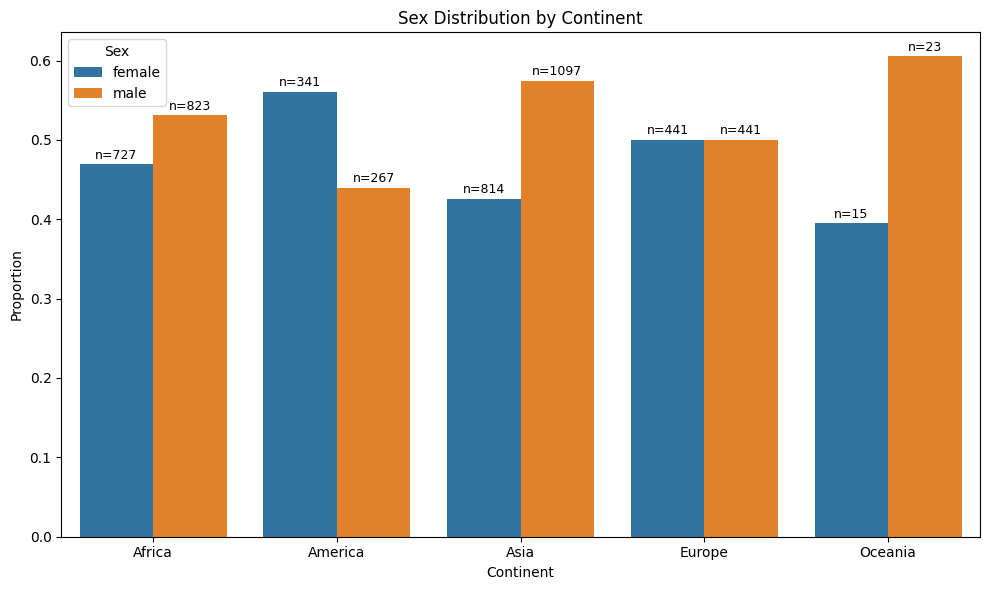

In [20]:


# === Data Preparation ===
sex_counts = df.groupby(['Continent', 'Sex']).size()
continent_totals = df.groupby('Continent').size()
sex_proportions = (sex_counts / continent_totals).reset_index(name='Proportion')

# === Create Plot ===
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=sex_proportions,
    x='Continent',
    y='Proportion',
    hue='Sex',
    ax=ax
)
ax.set_title('Sex Distribution by Continent')
ax.set_ylabel('Proportion')

# Loop through each bar group (idx=0: female, idx=1: male)
for idx, container in enumerate(ax.containers):
    # Extract every 2nd value starting at idx (separates female/male counts)
    #sex_counts contains the counts for each sex in each continent
    #we slice the array to get the counts for each sex in each continent
    #sex_counts.values = [
    #727,   # Africa female   (index 0)
    #823,   # Africa male     (index 1)
    #341,   # America female  (index 2)
    #267,   # America male    (index 3)
    #814,   # Asia female     (index 4)
    #1097,  # Asia male       (index 5)
    #441,   # Europe female   (index 6)
    #441,   # Europe male     (index 7)
    #15,    # Oceania female  (index 8)
    #23     # Oceania male    (index 9)

    sample_sizes = sex_counts.values[idx::2]
    # Create label strings like 'n=727' for each count
    labels = [f'n={n}' for n in sample_sizes]
    # Add labels on top of each bar in this group
    ax.bar_label(container, labels=labels, padding=2, fontsize=9)

plt.legend(title='Sex')
plt.tight_layout()
plt.show()

